# Etapa 1: Importação das bibliotecas

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import pandas as pd
caminho_arquivo = '/content/drive/MyDrive/Colab Notebooks/RNR/elon_musk_tweets.csv'

# Carregamento do dataset
df = pd.read_csv(caminho_arquivo)

# Exibir as primeiras linhas para confirmar
display(df.head(2))

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet
0,1544379368478212100,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240855,115,13503,True,2022-07-05 17:55:09+00:00,@BillyM2k I find the gold toe sock – inevitabl...,NaN,Twitter for iPhone,335,6542,False
1,1544377493263720450,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240806,115,13503,True,2022-07-05 17:47:42+00:00,"Sock Con, the conference for socks",NaN,Twitter for iPhone,1451,30753,False


In [5]:
import numpy as np
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout

# Função para limpar os tweets
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

text_data = df['clean_text']
print(f"Total de tweets selecionados: {len(text_data)}")

Total de tweets selecionados: 5904


# Passo 2: Tokenização e Preparação das Sequências

---



In [6]:
# Tokenização
tokenizer = Tokenizer()
tokenizer.fit_on_texts(text_data)
total_words = len(tokenizer.word_index) + 1

input_sequences = []
# Criando N-grams de palavras para o treinamento
for line in text_data:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

# Padronizando o tamanho das sequências
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

# Dividindo entre Preditores (X) e Rótulo (y)
X, y = input_sequences[:,:-1], input_sequences[:,-1]

# Passo 3: Criação das Arquiteturas

In [7]:
model1 = Sequential()
model1.add(Input(shape=(max_sequence_len-1,)))
model1.add(Embedding(input_dim=total_words, output_dim=100))
model1.add(LSTM(150))
model1.add(Dense(total_words, activation='softmax'))

model1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("Resumo do Modelo 1:")
model1.summary()

Resumo do Modelo 1:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 27, 100)        │       708,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7083)           │     1,069,533 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,928,433 (7.36 MB)

 Trainable params: 1,928,433 (7.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model2 = Sequential()
model2.add(Input(shape=(max_sequence_len-1,)))
model2.add(Embedding(input_dim=total_words, output_dim=100))
model2.add(LSTM(100, return_sequences=True))
model2.add(Dropout(0.1))
model2.add(LSTM(100))
model2.add(Dense(100, activation='relu'))
model2.add(Dense(total_words, activation='softmax'))

model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("\nResumo do Modelo 2:")
model2.summary()


Resumo do Modelo 2:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 27, 100)        │       708,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 27, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 27, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7083)           │       715,383 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,594,583 (6.08 MB)

 Trainable params: 1,594,583 (6.08 MB)

 Non-trainable params: 0 (0.00 B)

# Passo 4: Treinamento

In [10]:
# Configurando parada antecipada e salvamento do melhor modelo
es = EarlyStopping(monitor='loss', patience=5, verbose=1, restore_best_weights=True)

# Treinamento Modelo 1
print("Iniciando Treinamento do Modelo 1...")
history1 = model1.fit(X, y, epochs=50, batch_size=64, callbacks=[es], verbose=1)



Iniciando Treinamento do Modelo 1...
Epoch 1/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.0357 - loss: 7.2646
Epoch 2/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.0579 - loss: 6.7756
Epoch 3/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.0791 - loss: 6.4254
Epoch 4/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0957 - loss: 6.1054
Epoch 5/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1085 - loss: 5.8023
Epoch 6/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.1217 - loss: 5.5189
Epoch 7/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1349 - loss: 5.2511
Epoch 8/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1507 - loss: 4.9889
Epoch 9/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.1689 - loss: 4.7318
Epoch 10/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1918 - loss: 4.4763
Epoch 11/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2213 - loss: 4.2252
Epoch 12/50
68

In [12]:
# Treinamento Modelo 2
es = EarlyStopping(monitor='loss', patience=5, verbose=1, restore_best_weights=True)
print("\nIniciando Treinamento do Modelo 2...")
history2 = model2.fit(X, y, epochs=50, batch_size=64, callbacks=[es], verbose=1)


Iniciando Treinamento do Modelo 2...
Epoch 1/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4340 - loss: 2.4897
Epoch 2/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4433 - loss: 2.4526
Epoch 3/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4498 - loss: 2.4195
Epoch 4/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4517 - loss: 2.3967
Epoch 5/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4585 - loss: 2.3667
Epoch 6/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4609 - loss: 2.3480
Epoch 7/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4702 - loss: 2.3114
Epoch 8/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4741 - loss: 2.2835
Epoch 9/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4771 - loss: 2.2643
Epoch 10/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4799 - loss: 2.2417
Epoch 11/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4862 - loss: 2.2161
Epoch 12

# Passo 5: Geração de Tweets Automaticamente

In [13]:
def generate_tweet(model, tokenizer, seed_text, next_words, max_seq_len):
    for _ in range(next_words):
        # Transforma a semente numa sequência de tokens numéricos
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')

        # O modelo prevê o ID da próxima palavra
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)

        # Encontra a palavra correspondente ao ID
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        # Adiciona a palavra gerada à frase e continua o loop
        seed_text += " " + output_word

    return seed_text

# Textos de entrada (seed)
seed_1 = "space is"
seed_2 = "tesla will"

print("--- Textos Gerados pelo MODELO 1 ---")
print(generate_tweet(model1, tokenizer, seed_1, next_words=12, max_seq_len=max_sequence_len))

print("\n--- Textos Gerados pelo MODELO 2 ---")
print(generate_tweet(model2, tokenizer, seed_2, next_words=12, max_seq_len=max_sequence_len))

--- Textos Gerados pelo MODELO 1 ---
space is not asking to recoup past expenses but also cannot fund the existing

--- Textos Gerados pelo MODELO 2 ---
tesla will continue to use outside litigators but its lmk working to get the


# Análise de resultados

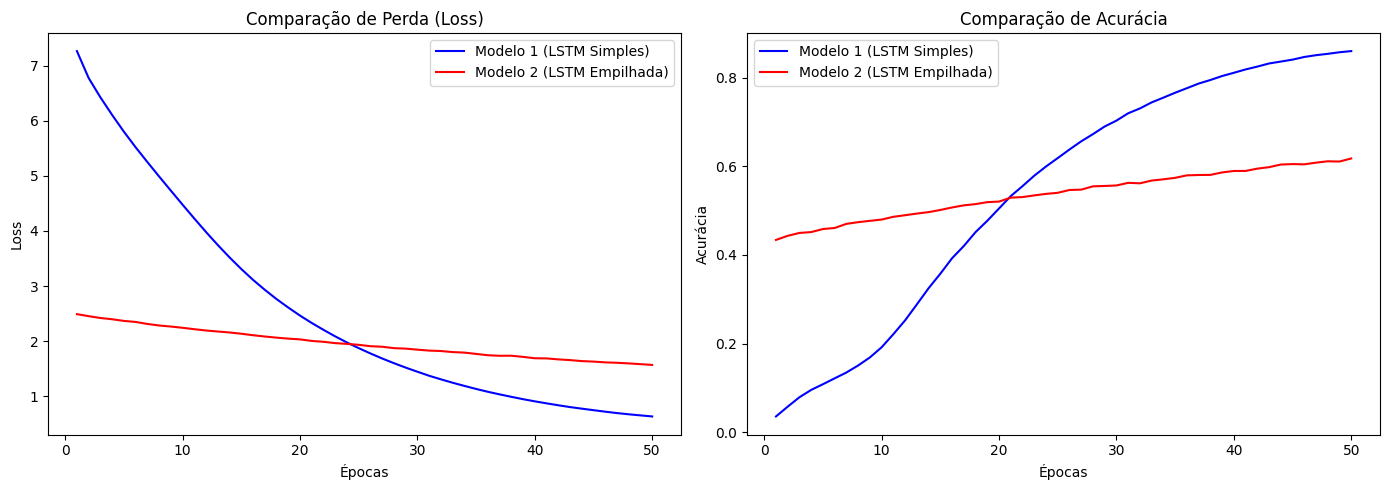

In [14]:
import matplotlib.pyplot as plt

# Extraindo a perda (loss) e acurácia de cada modelo
loss1 = history1.history['loss']
loss2 = history2.history['loss']
acc1 = history1.history['accuracy']
acc2 = history2.history['accuracy']
epocas1 = range(1, len(loss1) + 1)
epocas2 = range(1, len(loss2) + 1)

plt.figure(figsize=(14, 5))

# Gráfico de Perda (Loss) - Quanto MENOR, melhor
plt.subplot(1, 2, 1)
plt.plot(epocas1, loss1, 'b-', label='Modelo 1 (LSTM Simples)')
plt.plot(epocas2, loss2, 'r-', label='Modelo 2 (LSTM Empilhada)')
plt.title('Comparação de Perda (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Gráfico de Acurácia - Quanto MAIOR, melhor
plt.subplot(1, 2, 2)
plt.plot(epocas1, acc1, 'b-', label='Modelo 1 (LSTM Simples)')
plt.plot(epocas2, acc2, 'r-', label='Modelo 2 (LSTM Empilhada)')
plt.title('Comparação de Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
seed_testes = ["tesla is going to", "mars will be", "i think the future"]

print("------ TESTE DE GERAÇÃO ------ \n")

for seed in seed_testes:
    print(f"Semente inicial: '{seed}'")

    # Gerando com o Modelo 1
    texto_m1 = generate_tweet(model1, tokenizer, seed, next_words=20, max_seq_len=max_sequence_len)
    print(f"-> Modelo 1: {texto_m1}")

    # Gerando com o Modelo 2
    texto_m2 = generate_tweet(model2, tokenizer, seed, next_words=20, max_seq_len=max_sequence_len)
    print(f"-> Modelo 2: {texto_m2}")

    print("-" * 50)

------ TESTE DE GERAÇÃO ------ 

Semente inicial: 'tesla is going to'
-> Modelo 1: tesla is going to crush tennis way more convenient so maybe there are its a clear no losing things doing any bird in the
-> Modelo 2: tesla is going to overthrow the state service of the job is actually she will be great for correcting austin or competitors launch like
--------------------------------------------------
Semente inicial: 'mars will be'
-> Modelo 1: mars will be great for reducing impersonation risk but i will be doing going forward this particular i find out through creators in
-> Modelo 2: mars will be great for reducing impersonation risk on a zip code at the physics mind so can easily post within widespread tweet
--------------------------------------------------
Semente inicial: 'i think the future'
-> Modelo 1: i think the future of the simulation are all is a massive forcing function of 12 ads to go to prison for suggest it
-> Modelo 2: i think the future doesnt increase puppet softw